# 06 Hybrid Model

Bu notebook content-based ve collaborative filtering skorlarını birleştirir.

Temel soru:
- içerik benzerliği ile işbirlikçi sinyali hangi ağırlıklarla birleştirmek daha iyi sonuç veriyor?


## Not

Bu notebook sabit ağırlıklı hibrit yaklaşımın temel mantığını göstermek için tutulmaktadır. Final evaluation aşamasında kullanılan esas hibrit model ise `07_evaluation_and_comparison.ipynb` içinde yer alan dinamik CF-first rerank yaklaşımıdır.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_INTERIM = PROJECT_ROOT / "data_interim"

products_clean = pd.read_csv(DATA_INTERIM / "products_clean.csv")
cf_data = pd.read_csv(DATA_INTERIM / "reviews_cf_last.csv")

products_clean["product_id"] = products_clean["product_id"].astype(str)
cf_data["author_id"] = cf_data["author_id"].astype(str)
cf_data["product_id"] = cf_data["product_id"].astype(str)
cf_data["submission_time"] = pd.to_datetime(cf_data["submission_time"], errors="coerce")


/var/folders/tm/wc8rn0xj05v33kkcby8sf0fm0000gn/T/ipykernel_55032/2449715295.py:17: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cf_data = pd.read_csv(DATA_INTERIM / "reviews_cf_last.csv")


In [2]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(products_clean["product_text"].fillna(""))
similarity_matrix = cosine_similarity(tfidf_matrix)
productid_to_index = dict(zip(products_clean["product_id"], products_clean.index))
index_to_productid = dict(zip(products_clean.index, products_clean["product_id"]))

user_ids = cf_data["author_id"].unique()
item_ids = cf_data["product_id"].unique()
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
item_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids)}

cf_data["user_idx"] = cf_data["author_id"].map(user_to_idx)
cf_data["item_idx"] = cf_data["product_id"].map(item_to_idx)

matrix = csr_matrix((cf_data["rating"], (cf_data["user_idx"], cf_data["item_idx"])), shape=(len(user_ids), len(item_ids)))
svd = TruncatedSVD(n_components=50, random_state=42)
user_factors = svd.fit_transform(matrix)
item_factors = svd.components_.T
predicted_scores = user_factors @ item_factors.T


In [3]:
def get_seed_item_for_user(user_id):
    user_rows = cf_data[cf_data["author_id"] == user_id].copy()
    relevant_rows = user_rows[user_rows["rating"] >= 4].copy()
    if relevant_rows.empty:
        return None
    relevant_rows = relevant_rows.sort_values(by=["rating", "submission_time"], ascending=[False, False])
    return relevant_rows.iloc[0]["product_id"]


def min_max_normalize(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series([0] * len(series), index=series.index)
    return (series - min_val) / (max_val - min_val)


def recommend_hybrid(user_id, top_n=10, alpha=0.3):
    if user_id not in user_to_idx:
        return None

    seed_item = get_seed_item_for_user(user_id)
    if seed_item is None or seed_item not in productid_to_index:
        return None

    seed_index = productid_to_index[seed_item]
    seen_items = set(cf_data.loc[cf_data["author_id"] == user_id, "product_id"])

    content_rows = []
    for idx, score in sorted(enumerate(similarity_matrix[seed_index]), key=lambda x: x[1], reverse=True)[1:]:
        product_id = index_to_productid[idx]
        if product_id in seen_items:
            continue
        content_rows.append({"product_id": product_id, "similarity_score": score})
        if len(content_rows) >= 50:
            break

    content_rec = pd.DataFrame(content_rows)
    cf_rec = pd.DataFrame({"product_id": item_ids, "cf_score": predicted_scores[user_to_idx[user_id]]})
    cf_rec = cf_rec[~cf_rec["product_id"].isin(seen_items)].sort_values("cf_score", ascending=False).head(50)

    hybrid_df = content_rec.merge(cf_rec, on="product_id", how="outer")
    if hybrid_df.empty:
        return None

    hybrid_df["similarity_score"] = hybrid_df["similarity_score"].fillna(0)
    hybrid_df["cf_score"] = hybrid_df["cf_score"].fillna(0)
    hybrid_df["content_score_norm"] = min_max_normalize(hybrid_df["similarity_score"])
    hybrid_df["cf_score_norm"] = min_max_normalize(hybrid_df["cf_score"])
    hybrid_df["final_score"] = alpha * hybrid_df["content_score_norm"] + (1 - alpha) * hybrid_df["cf_score_norm"]

    return hybrid_df.sort_values("final_score", ascending=False).head(top_n)


,product_id,similarity_score,cf_score,content_score_norm,cf_score_norm,final_score
14,P427406,0.000000,0.261056,0.000000,1.000000,0.700000
19,P427414,0.256798,0.180992,0.574663,0.693307,0.657714
18,P427413,0.375735,0.147249,0.840821,0.564052,0.647083
21,P427416,0.276260,0.158034,0.618215,0.605362,0.609218
23,P427419,0.371205,0.093158,0.830683,0.356850,0.499000
24,P427420,0.275482,0.111524,0.616474,0.427202,0.483984
16,P427411,0.374086,0.077182,0.837131,0.295653,0.458096
47,P448530,0.323286,0.079720,0.723450,0.305376,0.430798
17,P427412,0.245271,0.085069,0.548868,0.325864,0.392766
20,P427415,0.000000,0.145242,0.000000,0.556363,0.389454


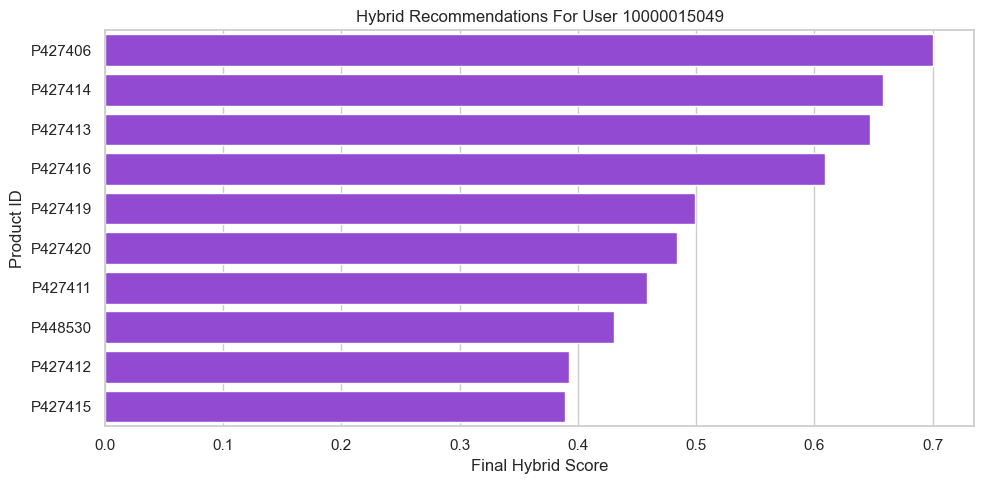

In [4]:
sample_user = cf_data["author_id"].iloc[0]
sample_hybrid = recommend_hybrid(sample_user, top_n=10, alpha=0.3)
display(sample_hybrid)

if sample_hybrid is not None:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=sample_hybrid, x="final_score", y="product_id", color="#9333EA")
    plt.title(f"Hybrid Recommendations For User {sample_user}")
    plt.xlabel("Final Hybrid Score")
    plt.ylabel("Product ID")
    plt.tight_layout()


## Sonuç Yorumu

Hybrid model çıktısı, içerik benzerliği ile collaborative filtering skorlarının birlikte kullanılması sayesinde daha dengeli bir sıralama üretebildiğini göstermektedir. Bu yapı, yalnızca benzer ürünleri değil aynı zamanda kullanıcı davranışıyla uyumlu ürünleri de öne çıkarır.


## Quick Alpha Tuning On A Sample

Asıl metrik karşılaştırması `07_evaluation_and_comparison.ipynb` içinde yapılmalı, ancak burada hibrit ağırlık mantığını hızlıca gözlemlemek faydalıdır.


,alpha,users_with_recommendations
0,0.1,177
1,0.3,177
2,0.5,177
3,0.7,177
4,0.9,177


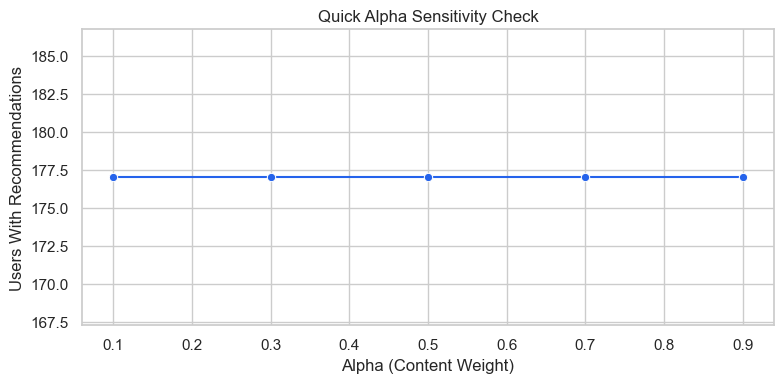

In [5]:
sample_users = cf_data["author_id"].drop_duplicates().head(200)
alpha_rows = []

for alpha in [0.1, 0.3, 0.5, 0.7, 0.9]:
    produced = 0
    for user_id in sample_users:
        recs = recommend_hybrid(user_id, top_n=10, alpha=alpha)
        if recs is not None and not recs.empty:
            produced += 1
    alpha_rows.append({"alpha": alpha, "users_with_recommendations": produced})

alpha_df = pd.DataFrame(alpha_rows)
display(alpha_df)

plt.figure(figsize=(8, 4))
sns.lineplot(data=alpha_df, x="alpha", y="users_with_recommendations", marker="o", color="#2563EB")
plt.title("Quick Alpha Sensitivity Check")
plt.xlabel("Alpha (Content Weight)")
plt.ylabel("Users With Recommendations")
plt.tight_layout()


## Grafik Yorumu

Farklı alpha değerlerinde öneri üretilebilen kullanıcı sayısının incelenmesi, hibrit modelin içerik ve işbirlikçi sinyallere ne kadar duyarlı olduğunu gözlemlemek için yararlıdır. Nihai alpha seçimi yine de evaluation notebook'unda ölçülen performans metriklerine göre yapılmalıdır.
